# Encontro 7 — Registros documentais e ética em pesquisa

**Disciplina:** Métodos e Técnicas de Pesquisa Quantitativa — Administração/UFMA

Neste notebook você vai:
1. Importar as **demonstrações financeiras** que as companhias abertas depositam na CVM —
o exemplo perfeito de **registro documental** como dado quantitativo;
2. Transformar contas contábeis em **variáveis de pesquisa** (receita, lucro, margem);
3. Discutir os **limites** dessa fonte documental;
4. Executar o **pré-teste** do seu questionário e importar as respostas;
5. Registrar as implicações **éticas** do seu projeto.

## Seção 1 — A fonte: dados abertos da CVM

Companhias abertas são obrigadas a publicar suas **Demonstrações Financeiras Padronizadas
(DFP)**, e a CVM as disponibiliza em dados abertos. Vamos baixar o pacote de 2024 e ler a
**DRE consolidada** (Demonstração do Resultado do Exercício).

Repare na natureza do dado: ninguém respondeu questionário — as empresas **produziram
esses registros** no seu funcionamento, sob norma contábil que os padroniza. É isso que
faz do documento um dado de pesquisa: **padronização + acesso + documentação**.

*(O download tem ~13 MB e pode levar um minuto.)*

In [1]:
import io
import zipfile

import pandas as pd
import requests

url_dfp = "https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/DFP/DADOS/dfp_cia_aberta_2024.zip"
resposta = requests.get(url_dfp, timeout=300)
pacote = zipfile.ZipFile(io.BytesIO(resposta.content))

dre = pd.read_csv(pacote.open("dfp_cia_aberta_DRE_con_2024.csv"),
                  sep=";", encoding="latin-1", dtype=str)
print("DRE consolidada:", dre.shape)
dre[["DENOM_CIA", "CD_CONTA", "DS_CONTA", "VL_CONTA"]].head(8)

DRE consolidada: (32776, 15)


,DENOM_CIA,CD_CONTA,DS_CONTA,VL_CONTA
0,BCO BRASIL S.A.,3.01,Receitas de Intermediação Financeira,265438605.0000000000
1,BCO BRASIL S.A.,3.01,Receitas de Intermediação Financeira,273505274.0000000000
2,BCO BRASIL S.A.,3.01.01,Receita de Juros,265438605.0000000000
3,BCO BRASIL S.A.,3.01.01,Receita de Juros,273505274.0000000000
4,BCO BRASIL S.A.,3.02,Despesas de Intermediação Financeira,-176689874.0000000000
5,BCO BRASIL S.A.,3.02,Despesas de Intermediação Financeira,-168990827.0000000000
6,BCO BRASIL S.A.,3.02.01,Despesa de Juros,-176689874.0000000000
7,BCO BRASIL S.A.,3.02.01,Despesa de Juros,-168990827.0000000000


Cada linha é **uma conta contábil de uma companhia**. As contas seguem um plano
padronizado — e é pelo **código da conta**, não pelo nome, que filtramos:

| Código | Conta |
|---|---|
| 3.01 | Receita de venda de bens e/ou serviços |
| 3.11 | Lucro/prejuízo consolidado do período |

Essa é a "gramática" do documento: quem não a conhece, não extrai o dado certo.

In [2]:
# Apenas o exercício mais recente de cada companhia
dre_ultimo = dre[dre["ORDEM_EXERC"] == "ÚLTIMO"].copy()
dre_ultimo["VL_CONTA"] = pd.to_numeric(dre_ultimo["VL_CONTA"], errors="coerce")

receita = dre_ultimo[dre_ultimo["CD_CONTA"] == "3.01"][["CD_CVM", "DENOM_CIA", "VL_CONTA"]]
receita = receita.rename(columns={"VL_CONTA": "receita"})

lucro = dre_ultimo[dre_ultimo["CD_CONTA"] == "3.11"][["CD_CVM", "VL_CONTA"]]
lucro = lucro.rename(columns={"VL_CONTA": "lucro_liquido"})

base = receita.merge(lucro, on="CD_CVM", how="inner").drop_duplicates(subset="CD_CVM")
base = base[base["receita"].notna() & (base["receita"] != 0)]
print("Companhias com receita e lucro:", len(base))
base.head()

Companhias com receita e lucro: 451


,CD_CVM,DENOM_CIA,receita,lucro_liquido
0,001023,BCO BRASIL S.A.,273505274.0,29171564.0
1,014206,BRB BANCO DE BRASILIA S.A.,8909356.0,311019.0
2,002437,AXIA ENERGIA S.A.,40181552.0,10380753.0
3,014451,COMPANHIA ENERGÉTICA DE BRASÍLIA - CEB,350369.0,225527.0
4,026190,CARAMURU ALIMENTOS S.A.,7272804.0,272076.0


Falta o **setor** — que está em outro documento: o cadastro de companhias da CVM. Juntar
dois registros documentais por uma chave comum (o código CVM) é operação típica dessa
técnica de coleta.

In [3]:
url_cad = "https://dados.cvm.gov.br/dados/CIA_ABERTA/CAD/DADOS/cad_cia_aberta.csv"
cadastro_cvm = pd.read_csv(url_cad, sep=";", encoding="latin-1", dtype=str)
cadastro_cvm = cadastro_cvm[cadastro_cvm["SIT"] == "ATIVO"][["CD_CVM", "SETOR_ATIV"]]

# O código CVM aparece com formatações diferentes nos dois arquivos — padronizamos:
base["chave"] = base["CD_CVM"].astype(float).astype(int)
cadastro_cvm["chave"] = cadastro_cvm["CD_CVM"].astype(float).astype(int)

base = base.merge(cadastro_cvm[["chave", "SETOR_ATIV"]], on="chave", how="left")
base = base.rename(columns={"SETOR_ATIV": "setor"}).drop(columns="chave")
print("Com setor:", base.shape)
base.head()

Com setor: (531, 5)


,CD_CVM,DENOM_CIA,receita,lucro_liquido,setor
0,001023,BCO BRASIL S.A.,273505274.0,29171564.0,Bancos
1,014206,BRB BANCO DE BRASILIA S.A.,8909356.0,311019.0,Bancos
2,002437,AXIA ENERGIA S.A.,40181552.0,10380753.0,Emp. Adm. Part. - Energia Elétrica
3,014451,COMPANHIA ENERGÉTICA DE BRASÍLIA - CEB,350369.0,225527.0,Energia Elétrica
4,026190,CARAMURU ALIMENTOS S.A.,7272804.0,272076.0,Alimentos


**Célula de contingência** — execute apenas se as células de download falharem (upload de
`dados/cvm_dre_2024.csv` no Colab). Ela entrega a mesma base final já construída.

In [4]:
import os
if "base" not in dir():
    for caminho in ("../../dados/cvm_dre_2024.csv", "cvm_dre_2024.csv"):
        if os.path.exists(caminho):
            base = pd.read_csv(caminho, dtype={"CD_CVM": str})
            print("Carregado do arquivo local:", caminho)
            break

> **📌 Nota de condução** — ~20 min até aqui (o download consome parte). Enfatize a lição metodológica: dado documental exige conhecer a gramática do documento (plano de contas, chaves de junção, escala em milhares) — e é essa gramática que garante comparabilidade entre empresas. Se a internet do laboratório estiver lenta, vá direto à contingência.

## Seção 2 — Da conta contábil à variável de pesquisa

A **margem líquida** (lucro ÷ receita) é uma operacionalização clássica de "desempenho"
sobre registro documental. Crie a variável e explore por setor:

In [5]:
base["margem_liquida"] = base["lucro_liquido"] / base["receita"]

margens_setor = (
    base.groupby("setor")["margem_liquida"]
    .agg(["count", "median"])
    .rename(columns={"count": "n_empresas", "median": "margem_mediana"})
    .query("n_empresas >= 8")
    .sort_values("margem_mediana", ascending=False)
)
(margens_setor.style.format({"margem_mediana": "{:.1%}"}))

,n_empresas,margem_mediana
setor,,
Emp. Adm. Part. - Comércio (Atacado e Varejo),10,29.6%
Emp. Adm. Part. - Energia Elétrica,23,18.2%
"Emp. Adm. Part. - Const. Civil, Mat. Const. e Decoração",13,17.9%
Energia Elétrica,38,15.6%
Bancos,9,9.3%
"Saneamento, Serv. Água e Gás",15,8.6%
Emp. Adm. Part. - Sem Setor Principal,13,8.5%
"Agricultura (Açúcar, Álcool e Cana)",13,5.9%
"Construção Civil, Mat. Constr. e Decoração",46,5.1%


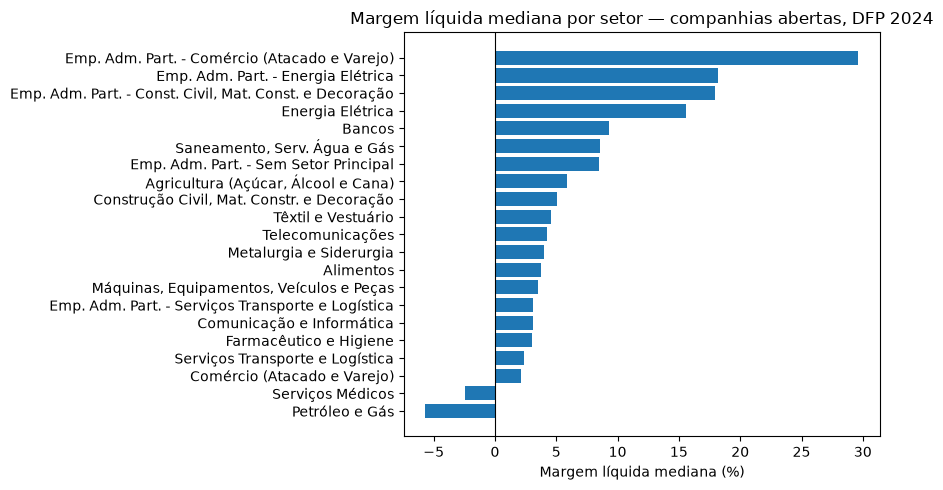

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.barh(margens_setor.index[::-1], margens_setor["margem_mediana"][::-1] * 100)
plt.xlabel("Margem líquida mediana (%)")
plt.title("Margem líquida mediana por setor — companhias abertas, DFP 2024")
plt.axvline(0, linewidth=0.8, color="black")
plt.tight_layout()
plt.show()

> **📌 Nota de condução** — Dois pontos de leitura: usamos a MEDIANA (não a média) porque margens têm valores extremos — gancho para o encontro 9; e margens negativas (prejuízo) são dado, não erro. Pergunte por que filtrar setores com n >= 8 antes de comparar medianas.

## Seção 3 — Limites do registro documental

Responda por escrito, editando esta célula:

**1.** Quem está **dentro** desta base? Quem está **fora**? (Pense: das milhões de
empresas brasileiras do CEMPRE, quantas são companhias abertas?)

*Sua resposta:*

**2.** Para quais perguntas de pesquisa esta base é **adequada** — e para quais seria
**enganosa**? Dê um exemplo de cada.

*Sua resposta:*

**3.** Bancos aparecem com margens muito diferentes das indústrias. Que cuidado isso impõe
ao comparar setores com dados contábeis?

*Sua resposta:*

## Seção 4 — Pré-teste do seu questionário

Compartilhe o link do seu questionário revisado com 3 a 5 colegas e responda aos deles.
Depois, importe as respostas:

**Como exportar do Google Formulários:** aba *Respostas* → ícone do Sheets → na planilha,
*Arquivo → Fazer download → CSV*. Faça o upload do arquivo aqui no Colab (ícone de pasta)
e ajuste o nome abaixo.

In [7]:
import os

arquivo_respostas = "respostas_pre_teste.csv"   # ajuste para o nome do seu arquivo

if os.path.exists(arquivo_respostas):
    respostas = pd.read_csv(arquivo_respostas)
    print("Respostas importadas:", respostas.shape)
    print("\nColunas (uma por pergunta):")
    for c in respostas.columns:
        print(" -", c[:80])
else:
    print("Arquivo não encontrado — faça o upload do CSV e reexecute esta célula.")

Arquivo não encontrado — faça o upload do CSV e reexecute esta célula.


In [8]:
# Diagnóstico simples do pré-teste: distribuição de respostas por pergunta fechada
if os.path.exists(arquivo_respostas):
    for coluna in respostas.columns[1:]:          # pula o carimbo de data/hora
        contagem = respostas[coluna].value_counts()
        if len(contagem) <= 8:                    # só perguntas fechadas
            print(f"\n== {coluna[:70]}")
            print(contagem.to_string())

**Registro do pré-teste** (edite esta célula):

**Duas mudanças que farei no questionário após ver as respostas:**

1.

2.

**O TCLE da tela inicial funcionou?** (Alguém começou a responder sem entender o que era?)

*Sua resposta:*

## Seção 5 — Ética: o registro do seu projeto

Responda por escrito, editando esta célula:

**1.** Seu projeto individual usa dados públicos e agregados (IBGE, BCB, CVM). Explique
por que ele se enquadra nas situações que a Resolução CNS nº 510/2016 dispensa de registro
em CEP — e cite **dois deveres éticos** que permanecem mesmo assim.

*Sua resposta:*

**2.** Se você transformasse seu projeto num survey com gestores (dados primários), o que
mudaria: TCLE? Submissão via Plataforma Brasil? Cuidados de anonimização (LGPD)?

*Sua resposta:*

**3.** Que registro documental existe na organização onde você trabalha (ou que conhece)
que permitiria pesquisa quantitativa? Que questões éticas o uso dele levantaria?

*Sua resposta:*

---
### Antes de sair

1. Salve e compartilhe o link do notebook;
2. **Próximo encontro é a Avaliação 1**: prova (parte conceitual + parte prática em
notebook) e entrega da primeira etapa do projeto;
3. **Revisão:** as sínteses teóricas ao final dos slides dos encontros 1 a 7 são o mapa;
reexecutar os notebooks é a revisão ativa;
4. **Projeto:** conclua problema, hipóteses, variáveis (com níveis), base escolhida e
matriz de amarração — entrega ao final da prova.